# 6CS012 Worksheet-1
## Image Understanding and Compression with PCA

---
## Exercise 1 — RGB Image Processing

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import io

url = 'data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBwgHBgkIBwgKCgkLDRYPDQwMDRsUFRAWIB0iIiAdHx8kKDQsJCYxJx8fLT0tMTU3Ojo6Iys/RD84QzQ5OjcBCgoKDQwNGg8PGjclHyU3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3N//AABEIAJQBBgMBIgACEQEDEQH/xAAbAAACAwEBAQAAAAAAAAAAAAADBAABAgUGB//EADwQAAICAQIEAwUFBgUFAQAAAAECAAMRBCEFEjFBE1FhBiJxgZEUMkJToQcWI1Kx0RUzcsHwF0NUYvFE/8QAGgEAAwEBAQEAAAAAAAAAAAAAAAECAwQFBv/EACkRAAICAQIGAQMFAAAAAAAAAAABAhEDEiEEBRMxQVEiFKHhFUJxgdH/2gAMAwEAAhEDEQA/APDYkhMdfjKInjmBQmg2JnEozNoAqvvGK3iOd4apt5NAdKo5jlSxDTnpOhSYy4h1SQpNpLaOyhSxMRS0R+0bRC4ykJirnBgWeataLO0sk0zwbPBs8wWjA0zQDvvNEwFhlJARrMd5Es3i7neZSwc3KM7HG0007AdKt43U85tLA7jpHqW6RaRUP1HeN1iJ0GPVTmyIxmHQS2WRDtLJnI0ZlKkMqTCmFUyooZfJKKTWZktNEgA2LFbhGrDtFbWgSxVxvJKcyRgBK9fjMlYYjr8ZWJsdIErMFYcrBsJLAAw3kQ4Mt5gHBkgdDTv0nSoecal8R6myKikzrI80WiKWw3ibRmlmrW2iFx6xix8iK2TRdiWxK2KvHLFi7LKJFjM8pMY8OWK4WKxcIZl6/SOrVLNMNQWcl6usiKVJK4BPUgTpNT6QRpmiyBYtWmI1VItcKiYg5BYxQY7W2IlXtDq2JlJWRIcWyWX2ifiYl+LMXAzobFkIt3rOf4srxvWNQHR0Td6yjd6znG/1mTf6y9ID1lvrFbLMxd7s94JrYnEmgzNJFvEkk0IfG8nLIkKFzNDcAV2gnUx3w4N6pNgc5xBRy2oxZkIkjKQ4MaqcxUAw9e0pIaY9U+T1xviPavS36PkNwUo4yjo3MrD0IhbNDXqRXVStVdyBVdxsCAN8/CFPMvAfs1w95WNgB/Cf+ZhGUWM5hbIgmlq3pJv3BB7gy0MCywZSMGZIgQ2A5PSaVIULCKshsQJU9Jrw/SHWuEFcVktibVbdIFqvSdI1+kw1ee0WoWo5vhy+XEcav0mGSWpDsXG03mRhgzBMpMZTNiYazEqxsRV3hQJB2tmDdFWeDNkpRHQ4bpk3xI2esybIaRNDpuz3mDbE/E9ZXPHoJHPE9ZIoHkhoCj1FUarXMUoMfpG0yaNaNCvaYav5RoLtMsuxkMqiafgratAzX00hvu8xJgtV7OugJq1mmtYfg5uUn6wuotK6MA5KAlWA6+YnBv1FyHHOzgdD5RL5OkZSdOiW6ayqxq7Uat16qwwROjwrRVvp7tRqk5q191QGI374iuk1DaxPBuPMQCa3PXA6j4YzOxqmTScO02jtYrayl8Y333zj4ScjklSNsUHN0jOhDX2va+1Sli7LtnPYR23S6ziFZXS6Z7GtYk8o2Uf/ADEFpbbbNPXpNNplU84JrOQ1nyx5TrNbpq7q6+F6mqriNaFSzDmJI7fD9YYcXytntY+UNxuYrwv2ZsfVYvtpssr946etsscefpAa72f4h41trVrY7MWZa2BYZPlPRcU1FlNVdum1VOluVeVnCgAsd8EntGr9Wa9Rp7Kvstl3L3AyzHrjPnO7RGhvluOtj51dprKTy2IyN5MMQRGJ9L1mho1LX6WzTHksGa2Lc/vdT6j+k8Vxnhdenqr1GjfxKbM7A5KnykTx0edn4KcFqW6OSBNqYMnfbMgaYuJwjSNDLiJLZD12dJDREkMEAzJQeUoPIXmcnRkwbLAOsOzQFjRxlZSF7BiLOcQ9hi1s3iWgVjbGK2GGcxeyaRRSAu0ETNtBNNEhlFpgtI0zLSEazJkygJeICovMkvEkQqPU0GdCgzk0tH6HmDNjpp0lNBV2bbGM10taAwdFB2958TKRYXTfZG0t1dlFllzAjmWzGB2YD08vjPM6/RajS2Fz71OdrEBKn+09DZpxS6tfqqlUHJKNkj4Yg143pV5ilFt3KCSTtkDzAyJOpVsDip1HyJ8MTTV2aa1APHJBCnoPLPzxOubx/jDjVDTlbrCGdwGZSvffp06dJ57iuppusZ66EQlQeWsACsHy9Yx4WkGo0r0W2E86MzWMDttn12OYQhvbPq+XcFHHBOS3Z6HS6bVafjov0mozQr4JZRjlxtynv2/WZ1d+n03GWqv0dbBXCCwXnmXnOzAZ2G/bpOZq7eI6Xij51B5BaoFQU8jVnG47H+8b1L8Qo4iLBebdOzjZqxyisjPMD6bzc7e7TuxriupOiu+xjQK2jPKWdWw2X2PXPN2BzN8ev4ZXdpaNRS2a61HilC6oCdt+vNt1E5XEuI63T67npsoeqtVelGrDFwevKTvkfGM8Y1l1Wsqe7Q+NWtalyjkEqT0I7jP/AASu9kKG6/09FrE8Pieiuo158V61UVeNjKjvy9/6xPnC3ayhKFrU372Mv8O1Ds3wPr5zla7U8O4rxTTgltO/KiszsU5SNwRjbOD3EPrm1B4hrNOFFmgs+8yfhCgMT127xuREMH7Zfc4PGNKNDrbaVJKo2MnsfImIk+s9NxLTWajRhFdLq6qvES/u5x0PrPKtscSaPl+YcL0MtLswgaFSyKc02ryZI85jwskNkUDy/EnLNbmLQZ3gXeYayAd44IaRpngnMotmUd50xRogbCBdI1yyik1oYiyQLpH3rgWSLVQrEWSZ5I2yTHJK1AA5ZYWG5JfJGmMCFkhwskQHUraN1POfW0YraZM0OnVYdp0dHallT1O4R8hkztv5Tj6a0JYrOnOoIJX+b0ndbh+gtHi6TiGajv4bJixfQ74kSimtx2cTX06trvDRbGycDG4zFL0bSUCl7Rkn3wm+PnOzq6dXnw9KiUVsN7GcF2Hx7fLHznG1FdS12JWKwi1EIebuDvj6frJhFeD0eW4FlzXLsgltyodRptIQ6WPnxLAMsuB1z06RevT2WUPc2FRQQDzY94DOPie0iWLTZXd4YyK84RieRuzbn9Om8WW7UVV2FGKVWfeVemPh5Taj69TpVHYfq1mt11ddT3lKAQhYvyquemT8pjSPqtdSaxc7BACas5OM7kAdcdcRajUW6RWOnsIDbHKgqcdt+uJA1wB1otK2BgebIBOe4HltHQtau7OpouIa7h1j6ap2ZC38IMNjvsRncQul4tq6b6LNaE1VXPnlsUc1ZB3G3TfsdpxybLQ99th8QAFSz7sM9vPH+8aGs1WsXwiy85TmZlrUO/L3J6nEVAnF9/Hc7lOu0Gv4mLNevhV2tnwymQzDYEHt0G0Z0lOr0H27VUlW0/K62q6nbLYAB88GcPSa/RJSr2VWs33lpLL4at/Mud/lvGtGdX4dt1Ts2nKvdqEDNsB7wbfbt2iYKP8AS9M7GhVLNLQmgax1ttH2igMMjBHTbznnuJ6ZtPqGBBAf3lz6z0NVuk1lOm+y2PRqqbf4jKoBDkjB8j0gPaPQWlWsNRU02OC+cq67nI8vWM8nm2HqYrS3R5YmaBgyZWfWI+SYUtiZNkGTtMk46zOUUQ0bNkGWlEyoJAjQMIIEZhVm0RhFE1yyKIQSwAOkAyCPFYFlmUiGxJkmSkbKQbJgxJjsX5cTPLGGWDImkZFJgpJZlzTYZ9O/cWgdjND2IpHQN9Z9JKL5SvDXynb0o+jSj52nsZUOzQyexlPk2Z77w08oLU2Lp6S4pe09krXJJieKC3oKPlftJo9Jwe/T6WtTZqLd2UHcL6eRM41uiXQ/Z31NKuTYVr/iEDlbcc3rgz2t3svxDX8U1PHuLYpNQNldKnJOBsvoJ4zUpZrNR4mpNWbKymoTcEWIDnl+YE49G7dUe3yptKRzOahbbNKq11qWUIRnmfm6HP0iTVclRUL7+SCeTt06+Ua1F1RaiytaiictZZlPuY7xe661LC6lmVgCmD94+vnFR7er2ZwGRK2WsN2bLZP649OksmxdN4fiE083QgHG/bylMqqzrlFLNkNzEHbt1xLswCzPgZ6L2bz7RNF6q3Zs23aekVeIUWwZavfHzB7/AAmqbvs9PMi1ujNgLYA+49Oqn4QDMQ1hwMIO++fT0hLGFikO4/hIDkheblzjGep6jaKhxnWzY3pLEpBu1PiGu8tW7VFSw8wVPY/Kdu3iROmGl4Tc1WnVW50ZRynI2HTv9Mzzl2pst0wy/OiFUJ5Vz6DPWOFvsZov0mrQ3KcK9TkmwHuVP3T6dJL2NE1J+39j09jaDT8JoTWqyay8qxV8bKu2C2PI7E7xu/S3VKmnqfx9EaRYyM3MThSSc99siee0Wr8XWp/iuoayixcM5XxMeaEbeU7GGu1Gp4jwy8jTaepjjGxUL0+OQdsCKyHGtn23/gco9lNJqahbQodDnDKcgyH2OpB/y51/YziaWBtI2n8I1qOZR0D75x6H+89QzV+QnoY1Gcbo+M43h+hlcT5+fZCn+SaX2Oo71z3maztgTBr7qcS+lH0cdHil9jNOf+2Jr9ydOT/liezHOvkZa3svVR9I+jD0FHjR7D0flza+w+n/ACp7RdUP5RCDVp3EfSj6HR4oexWn/Ll/uZp/y57ddVR3xNi+lumI+nH0GlHhf3M0/wCXMn2M0/5c99zVHuJk8npF0o+g0I8D+5mm/LlfuXpvy573APlLWsnsIulD0LQj5+fYnSn/ALUr9yNJ+XPoRr/9RMlfQRrHFeA0I+f/ALjaT8uSfQOX0EkrQvQ9Jn7QD2k8UYmzQnpK8CvzgaFeID3lhvWTwK/5pPCRfxQGXdVVqqX096K9Vgw6nuJ8j9t9Ffp+I2C6g1iotZp3rHvMuPeGTsTjefXgUxjnE5ntHwpeL8Oequ0JqVGaX8j5HzB6ETOcdSOnhc/RnufCLraUR9Rp6Sarznwy21ZJi19jeIOVx4fTbG/pmdTjPCtXwnWXaLV4C2EkNucMPLPUTg+MG05V/vVk74GJyNH0Uc0WriFuwDnmXJB+8M5Bm3YKysefmAx09MRJrmKK/wCIbZPlNG4DlYMXAHvZ7doqDqIar/yxjII9PeAhV3pPMfvsFIzgHfY+kSruKoGGMnbBOTibFvOMBAAPez3MVGkcnmxtmLV8hUFq25QFUEny97GSIWkA2vUQQqA7qRknG3Xt6bRXxFFTeEWycFNhufXMMpUlDlcHdxk+99N5LRtGdefydDS67V2LSl7K61uDhxkfA+Y7RytfB+0jQ6linhmw1qdj5rv97A6TkaNnXHi8prDZ5bM+96bbx/hQtpD3M7IFPMDyh+XfAO/ymLR2Rmq9HquDcQvuu0VvKtXK6KX/ADQWCtk+e8+itpfLIPrPnXstQdTxThvuiylDn3k2O4OTv1GCek+qc2/n6zv4S1Hc+W51oeVaTmnSPNDT2CdIMMdJeR5TrPEo5vJYOqycjYwUnSyDLOPIQCjmBB/J+kpq1P4SJ1AB5CDbk7rGFHPXS1N1bEjaBSfds/WOmuo9pg6ZD90kfOAqFP8AD7O1hmG0WpHSzMbOkb8NzCZ+z3g/5+0BUJmnWL0IkD65eqZjpXUj7rqfjMltaPwK0AoXGr1S9azNDX2/iqMIbdWB72mBg/tFw+/pYwosa4/lmSUNUo+9pSPlKgMN9pbzWYOrxvsZGpEGdOCei49IqKss6/HQIPiZk8RI3IQ/ODbR82BgA+kC/DS3ciKgDNxikD31UGLW8e0lW7cvyMy3BQwOW/3ilvs3W2c4PyioBXjPFeAcXo+z8SpV0ByDuCPn5T5n7Q+zqi59RwjiC6pW60uOR/7GfSNV7I6c4zzZ8hOfd7DrZnks8Nf1MiULOjFlnDyfGbbLtLYyW1FD3VgdoNdRyHZjg9QO8+r3/s2otY89znPcnpFW/ZXpj/8AosHyk9M6PqX7PmY1PK2fdKt2O+JuvUgDdu/SfR/+lOm/8mz6zP8A0ooJwNbavwAMTxFR4uSZ4OjVqFPM3vfhXtD038zLzMByDIy36Ce+o/ZelFJUa9irdeelGlN+ylbXJXiVi+iUqBIeE3jzCnueNr1QsK4KgBs82MNv2PpO3pzVqbKK2sPPZlRyeXcTuU/sppAKvxXV49KlnoeB+w+k4Q/iafV3tZ3dlGf6SPp2dH6okvidD2W4VZwpnv1AUBkArQdUHrPRrqU9Tn4xOrSMhBe5337xxUGMZOe064QUVSPDzZJZZapG/HrUYOBjzaES3n6NX6YOczCpaBgKvzMh0pc5bA/0kjH6yzIPv3H0lYyd+YiC8BAQQTt5OZsIOQgPYT580ACha13JK+U17pXOST8Iu9DOMC21c9xBijUp01Wf9VeT/WADJJGwrJ9cTQDHYrgeomajcFwxXPop3/WWXsXqvyzAZfKe2PpJyt5AwZvsH4AT8ZDqW2zU4Ppg/wC8YtjZRj2xJyNiCbUnGPDuz/pJmvHVlPMr5HbBEKDY1yv/ADGTDfi3mTqF7Dl88zI1KMM57fSIDZ3/AASoJLhzEc6fWSA9jLSBRJJGM3yKBkDeTlBkkiAojAMy3XAAGfSSSMEBAY2nLtsPIf2muXnfDEySQGYNFbbsM7TRpr5R7suSIAVVaEnKgw3grjO+8kkYyJp6i4ysI1CAHHN9ZJJLGLWMETCov6zVZLAHOM9hJJEPwHQAHl3x8ZbqASfSSSNEM1UvmzH5worB7t9ZJIyS/CTuoMi1pnZQPgJJIgLsGCAJASAfeJ+MkkoZsCYOeblycSSQAmMkgk4kAAxiSSAjeARvMkYQ4kkgIxz7EFVPymQiM2Co+kqSIYC9ETGEX6SSSRiP/9k='
with urllib.request.urlopen(url) as response:
    img_data = response.read()

img_pil = Image.open(io.BytesIO(img_data)).convert('RGB')
img = np.array(img_pil)

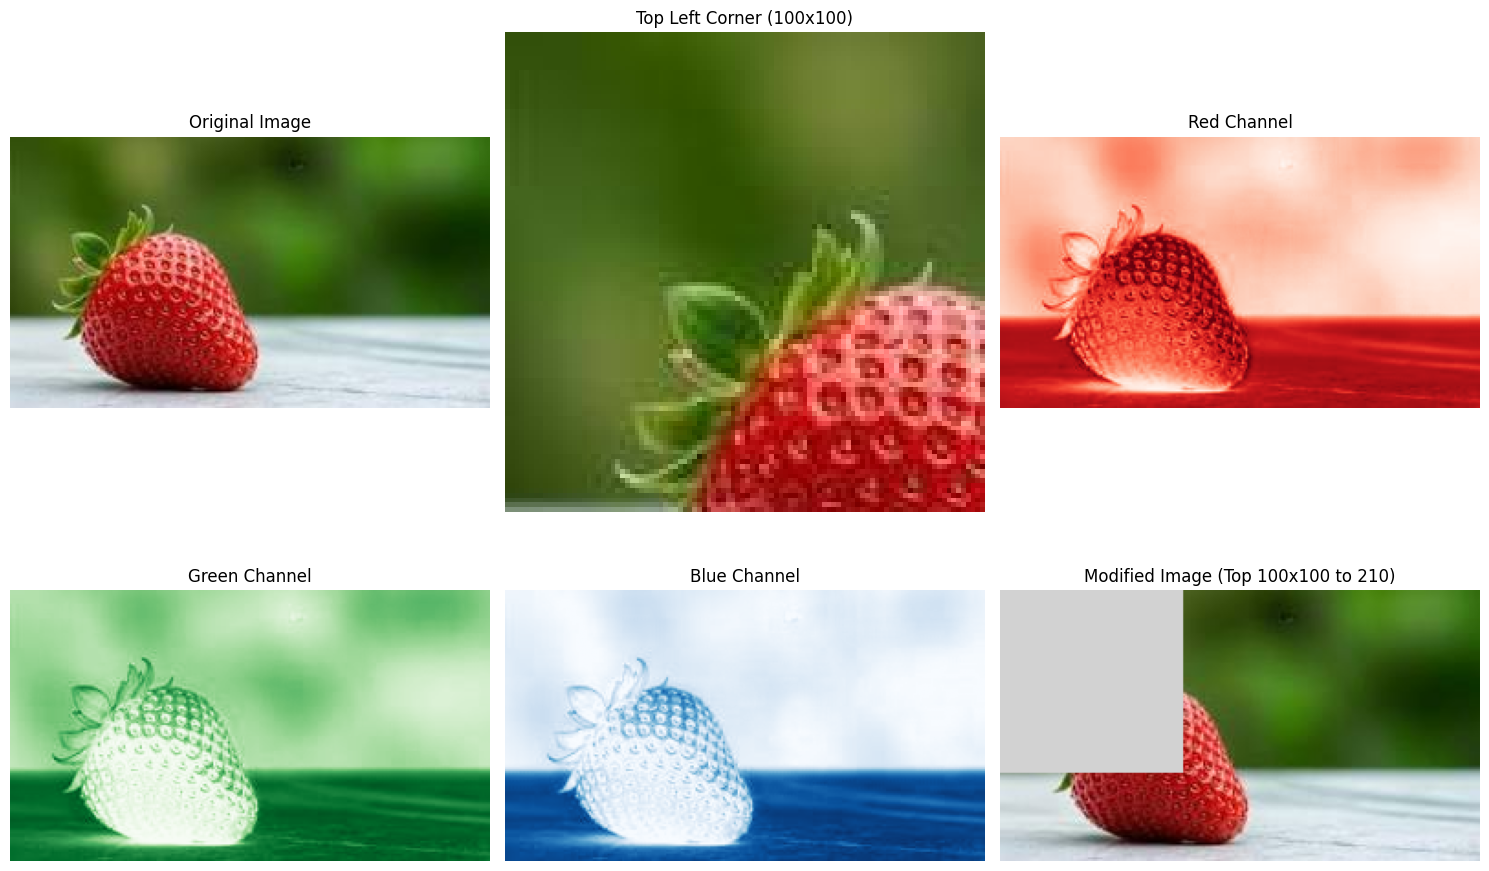

In [4]:
# Task 1 — Read and display
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Task 2 — Top-left 100x100
top_left = img[:100, :100]
axes[0, 1].imshow(top_left)
axes[0, 1].set_title('Top Left Corner (100x100)')
axes[0, 1].axis('off')

# Task 3 — R, G, B channels
R, G, B = img[:, :, 0], img[:, :, 1], img[:, :, 2]

axes[0, 2].imshow(R, cmap='Reds')
axes[0, 2].set_title('Red Channel')
axes[0, 2].axis('off')

axes[1, 0].imshow(G, cmap='Greens')
axes[1, 0].set_title('Green Channel')
axes[1, 0].axis('off')

axes[1, 1].imshow(B, cmap='Blues')
axes[1, 1].set_title('Blue Channel')
axes[1, 1].axis('off')

# Task 4 — Modify top 100x100 to 210
img_modified = img.copy()
img_modified[:100, :100] = 210

axes[1, 2].imshow(img_modified)
axes[1, 2].set_title('Modified Image (Top 100x100 to 210)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

---
## Exercise 2 — Grayscale Image Processing

In [6]:
gray_url = 'data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD/2wCEAAkGBwgHBgkIBwgKCgkLDRYPDQwMDRsUFRAWIB0iIiAdHx8kKDQsJCYxJx8fLT0tMTU3Ojo6Iys/RD84QzQ5OjcBCgoKDQwNGg8PGjclHyU3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3Nzc3N//AABEIAJQBBgMBIgACEQEDEQH/xAAbAAACAwEBAQAAAAAAAAAAAAADBAABAgUGB//EADwQAAICAQIEAwUFBgUFAQAAAAECAAMRBCEFEjFBE1FhBiJxgZEUMkJToQcWI1Kx0RUzcsHwF0NUYvFE/8QAGgEAAwEBAQEAAAAAAAAAAAAAAAECAwQFBv/EACkRAAICAQIGAQMFAAAAAAAAAAABAhEDEiEEBRMxQVEiFKHhFUJxgdH/2gAMAwEAAhEDEQA/APDYkhMdfjKInjmBQmg2JnEozNoAqvvGK3iOd4apt5NAdKo5jlSxDTnpOhSYy4h1SQpNpLaOyhSxMRS0R+0bRC4ykJirnBgWeataLO0sk0zwbPBs8wWjA0zQDvvNEwFhlJARrMd5Es3i7neZSwc3KM7HG0007AdKt43U85tLA7jpHqW6RaRUP1HeN1iJ0GPVTmyIxmHQS2WRDtLJnI0ZlKkMqTCmFUyooZfJKKTWZktNEgA2LFbhGrDtFbWgSxVxvJKcyRgBK9fjMlYYjr8ZWJsdIErMFYcrBsJLAAw3kQ4Mt5gHBkgdDTv0nSoecal8R6myKikzrI80WiKWw3ibRmlmrW2iFx6xix8iK2TRdiWxK2KvHLFi7LKJFjM8pMY8OWK4WKxcIZl6/SOrVLNMNQWcl6usiKVJK4BPUgTpNT6QRpmiyBYtWmI1VItcKiYg5BYxQY7W2IlXtDq2JlJWRIcWyWX2ifiYl+LMXAzobFkIt3rOf4srxvWNQHR0Td6yjd6znG/1mTf6y9ID1lvrFbLMxd7s94JrYnEmgzNJFvEkk0IfG8nLIkKFzNDcAV2gnUx3w4N6pNgc5xBRy2oxZkIkjKQ4MaqcxUAw9e0pIaY9U+T1xviPavS36PkNwUo4yjo3MrD0IhbNDXqRXVStVdyBVdxsCAN8/CFPMvAfs1w95WNgB/Cf+ZhGUWM5hbIgmlq3pJv3BB7gy0MCywZSMGZIgQ2A5PSaVIULCKshsQJU9Jrw/SHWuEFcVktibVbdIFqvSdI1+kw1ee0WoWo5vhy+XEcav0mGSWpDsXG03mRhgzBMpMZTNiYazEqxsRV3hQJB2tmDdFWeDNkpRHQ4bpk3xI2esybIaRNDpuz3mDbE/E9ZXPHoJHPE9ZIoHkhoCj1FUarXMUoMfpG0yaNaNCvaYav5RoLtMsuxkMqiafgratAzX00hvu8xJgtV7OugJq1mmtYfg5uUn6wuotK6MA5KAlWA6+YnBv1FyHHOzgdD5RL5OkZSdOiW6ayqxq7Uat16qwwROjwrRVvp7tRqk5q191QGI374iuk1DaxPBuPMQCa3PXA6j4YzOxqmTScO02jtYrayl8Y333zj4ScjklSNsUHN0jOhDX2va+1Sli7LtnPYR23S6ziFZXS6Z7GtYk8o2Uf/ADEFpbbbNPXpNNplU84JrOQ1nyx5TrNbpq7q6+F6mqriNaFSzDmJI7fD9YYcXytntY+UNxuYrwv2ZsfVYvtpssr946etsscefpAa72f4h41trVrY7MWZa2BYZPlPRcU1FlNVdum1VOluVeVnCgAsd8EntGr9Wa9Rp7Kvstl3L3AyzHrjPnO7RGhvluOtj51dprKTy2IyN5MMQRGJ9L1mho1LX6WzTHksGa2Lc/vdT6j+k8Vxnhdenqr1GjfxKbM7A5KnykTx0edn4KcFqW6OSBNqYMnfbMgaYuJwjSNDLiJLZD12dJDREkMEAzJQeUoPIXmcnRkwbLAOsOzQFjRxlZSF7BiLOcQ9hi1s3iWgVjbGK2GGcxeyaRRSAu0ETNtBNNEhlFpgtI0zLSEazJkygJeICovMkvEkQqPU0GdCgzk0tH6HmDNjpp0lNBV2bbGM10taAwdFB2958TKRYXTfZG0t1dlFllzAjmWzGB2YD08vjPM6/RajS2Fz71OdrEBKn+09DZpxS6tfqqlUHJKNkj4Yg143pV5ilFt3KCSTtkDzAyJOpVsDip1HyJ8MTTV2aa1APHJBCnoPLPzxOubx/jDjVDTlbrCGdwGZSvffp06dJ57iuppusZ66EQlQeWsACsHy9Yx4WkGo0r0W2E86MzWMDttn12OYQhvbPq+XcFHHBOS3Z6HS6bVafjov0mozQr4JZRjlxtynv2/WZ1d+n03GWqv0dbBXCCwXnmXnOzAZ2G/bpOZq7eI6Xij51B5BaoFQU8jVnG47H+8b1L8Qo4iLBebdOzjZqxyisjPMD6bzc7e7TuxriupOiu+xjQK2jPKWdWw2X2PXPN2BzN8ev4ZXdpaNRS2a61HilC6oCdt+vNt1E5XEuI63T67npsoeqtVelGrDFwevKTvkfGM8Y1l1Wsqe7Q+NWtalyjkEqT0I7jP/AASu9kKG6/09FrE8Pieiuo158V61UVeNjKjvy9/6xPnC3ayhKFrU372Mv8O1Ds3wPr5zla7U8O4rxTTgltO/KiszsU5SNwRjbOD3EPrm1B4hrNOFFmgs+8yfhCgMT127xuREMH7Zfc4PGNKNDrbaVJKo2MnsfImIk+s9NxLTWajRhFdLq6qvES/u5x0PrPKtscSaPl+YcL0MtLswgaFSyKc02ryZI85jwskNkUDy/EnLNbmLQZ3gXeYayAd44IaRpngnMotmUd50xRogbCBdI1yyik1oYiyQLpH3rgWSLVQrEWSZ5I2yTHJK1AA5ZYWG5JfJGmMCFkhwskQHUraN1POfW0YraZM0OnVYdp0dHallT1O4R8hkztv5Tj6a0JYrOnOoIJX+b0ndbh+gtHi6TiGajv4bJixfQ74kSimtx2cTX06trvDRbGycDG4zFL0bSUCl7Rkn3wm+PnOzq6dXnw9KiUVsN7GcF2Hx7fLHznG1FdS12JWKwi1EIebuDvj6frJhFeD0eW4FlzXLsgltyodRptIQ6WPnxLAMsuB1z06RevT2WUPc2FRQQDzY94DOPie0iWLTZXd4YyK84RieRuzbn9Om8WW7UVV2FGKVWfeVemPh5Taj69TpVHYfq1mt11ddT3lKAQhYvyquemT8pjSPqtdSaxc7BACas5OM7kAdcdcRajUW6RWOnsIDbHKgqcdt+uJA1wB1otK2BgebIBOe4HltHQtau7OpouIa7h1j6ap2ZC38IMNjvsRncQul4tq6b6LNaE1VXPnlsUc1ZB3G3TfsdpxybLQ99th8QAFSz7sM9vPH+8aGs1WsXwiy85TmZlrUO/L3J6nEVAnF9/Hc7lOu0Gv4mLNevhV2tnwymQzDYEHt0G0Z0lOr0H27VUlW0/K62q6nbLYAB88GcPSa/RJSr2VWs33lpLL4at/Mud/lvGtGdX4dt1Ts2nKvdqEDNsB7wbfbt2iYKP8AS9M7GhVLNLQmgax1ttH2igMMjBHTbznnuJ6ZtPqGBBAf3lz6z0NVuk1lOm+y2PRqqbf4jKoBDkjB8j0gPaPQWlWsNRU02OC+cq67nI8vWM8nm2HqYrS3R5YmaBgyZWfWI+SYUtiZNkGTtMk46zOUUQ0bNkGWlEyoJAjQMIIEZhVm0RhFE1yyKIQSwAOkAyCPFYFlmUiGxJkmSkbKQbJgxJjsX5cTPLGGWDImkZFJgpJZlzTYZ9O/cWgdjND2IpHQN9Z9JKL5SvDXynb0o+jSj52nsZUOzQyexlPk2Z77w08oLU2Lp6S4pe09krXJJieKC3oKPlftJo9Jwe/T6WtTZqLd2UHcL6eRM41uiXQ/Z31NKuTYVr/iEDlbcc3rgz2t3svxDX8U1PHuLYpNQNldKnJOBsvoJ4zUpZrNR4mpNWbKymoTcEWIDnl+YE49G7dUe3yptKRzOahbbNKq11qWUIRnmfm6HP0iTVclRUL7+SCeTt06+Ua1F1RaiytaiictZZlPuY7xe661LC6lmVgCmD94+vnFR7er2ZwGRK2WsN2bLZP649OksmxdN4fiE083QgHG/bylMqqzrlFLNkNzEHbt1xLswCzPgZ6L2bz7RNF6q3Zs23aekVeIUWwZavfHzB7/AAmqbvs9PMi1ujNgLYA+49Oqn4QDMQ1hwMIO++fT0hLGFikO4/hIDkheblzjGep6jaKhxnWzY3pLEpBu1PiGu8tW7VFSw8wVPY/Kdu3iROmGl4Tc1WnVW50ZRynI2HTv9Mzzl2pst0wy/OiFUJ5Vz6DPWOFvsZov0mrQ3KcK9TkmwHuVP3T6dJL2NE1J+39j09jaDT8JoTWqyay8qxV8bKu2C2PI7E7xu/S3VKmnqfx9EaRYyM3MThSSc99siee0Wr8XWp/iuoayixcM5XxMeaEbeU7GGu1Gp4jwy8jTaepjjGxUL0+OQdsCKyHGtn23/gco9lNJqahbQodDnDKcgyH2OpB/y51/YziaWBtI2n8I1qOZR0D75x6H+89QzV+QnoY1Gcbo+M43h+hlcT5+fZCn+SaX2Oo71z3maztgTBr7qcS+lH0cdHil9jNOf+2Jr9ydOT/liezHOvkZa3svVR9I+jD0FHjR7D0flza+w+n/ACp7RdUP5RCDVp3EfSj6HR4oexWn/Ll/uZp/y57ddVR3xNi+lumI+nH0GlHhf3M0/wCXMn2M0/5c99zVHuJk8npF0o+g0I8D+5mm/LlfuXpvy573APlLWsnsIulD0LQj5+fYnSn/ALUr9yNJ+XPoRr/9RMlfQRrHFeA0I+f/ALjaT8uSfQOX0EkrQvQ9Jn7QD2k8UYmzQnpK8CvzgaFeID3lhvWTwK/5pPCRfxQGXdVVqqX096K9Vgw6nuJ8j9t9Ffp+I2C6g1iotZp3rHvMuPeGTsTjefXgUxjnE5ntHwpeL8Oequ0JqVGaX8j5HzB6ETOcdSOnhc/RnufCLraUR9Rp6Sarznwy21ZJi19jeIOVx4fTbG/pmdTjPCtXwnWXaLV4C2EkNucMPLPUTg+MG05V/vVk74GJyNH0Uc0WriFuwDnmXJB+8M5Bm3YKysefmAx09MRJrmKK/wCIbZPlNG4DlYMXAHvZ7doqDqIar/yxjII9PeAhV3pPMfvsFIzgHfY+kSruKoGGMnbBOTibFvOMBAAPez3MVGkcnmxtmLV8hUFq25QFUEny97GSIWkA2vUQQqA7qRknG3Xt6bRXxFFTeEWycFNhufXMMpUlDlcHdxk+99N5LRtGdefydDS67V2LSl7K61uDhxkfA+Y7RytfB+0jQ6linhmw1qdj5rv97A6TkaNnXHi8prDZ5bM+96bbx/hQtpD3M7IFPMDyh+XfAO/ymLR2Rmq9HquDcQvuu0VvKtXK6KX/ADQWCtk+e8+itpfLIPrPnXstQdTxThvuiylDn3k2O4OTv1GCek+qc2/n6zv4S1Hc+W51oeVaTmnSPNDT2CdIMMdJeR5TrPEo5vJYOqycjYwUnSyDLOPIQCjmBB/J+kpq1P4SJ1AB5CDbk7rGFHPXS1N1bEjaBSfds/WOmuo9pg6ZD90kfOAqFP8AD7O1hmG0WpHSzMbOkb8NzCZ+z3g/5+0BUJmnWL0IkD65eqZjpXUj7rqfjMltaPwK0AoXGr1S9azNDX2/iqMIbdWB72mBg/tFw+/pYwosa4/lmSUNUo+9pSPlKgMN9pbzWYOrxvsZGpEGdOCei49IqKss6/HQIPiZk8RI3IQ/ODbR82BgA+kC/DS3ciKgDNxikD31UGLW8e0lW7cvyMy3BQwOW/3ilvs3W2c4PyioBXjPFeAcXo+z8SpV0ByDuCPn5T5n7Q+zqi59RwjiC6pW60uOR/7GfSNV7I6c4zzZ8hOfd7DrZnks8Nf1MiULOjFlnDyfGbbLtLYyW1FD3VgdoNdRyHZjg9QO8+r3/s2otY89znPcnpFW/ZXpj/8AosHyk9M6PqX7PmY1PK2fdKt2O+JuvUgDdu/SfR/+lOm/8mz6zP8A0ooJwNbavwAMTxFR4uSZ4OjVqFPM3vfhXtD038zLzMByDIy36Ce+o/ZelFJUa9irdeelGlN+ylbXJXiVi+iUqBIeE3jzCnueNr1QsK4KgBs82MNv2PpO3pzVqbKK2sPPZlRyeXcTuU/sppAKvxXV49KlnoeB+w+k4Q/iafV3tZ3dlGf6SPp2dH6okvidD2W4VZwpnv1AUBkArQdUHrPRrqU9Tn4xOrSMhBe5337xxUGMZOe064QUVSPDzZJZZapG/HrUYOBjzaES3n6NX6YOczCpaBgKvzMh0pc5bA/0kjH6yzIPv3H0lYyd+YiC8BAQQTt5OZsIOQgPYT580ACha13JK+U17pXOST8Iu9DOMC21c9xBijUp01Wf9VeT/WADJJGwrJ9cTQDHYrgeomajcFwxXPop3/WWXsXqvyzAZfKe2PpJyt5AwZvsH4AT8ZDqW2zU4Ppg/wC8YtjZRj2xJyNiCbUnGPDuz/pJmvHVlPMr5HbBEKDY1yv/ADGTDfi3mTqF7Dl88zI1KMM57fSIDZ3/AASoJLhzEc6fWSA9jLSBRJJGM3yKBkDeTlBkkiAojAMy3XAAGfSSSMEBAY2nLtsPIf2muXnfDEySQGYNFbbsM7TRpr5R7suSIAVVaEnKgw3grjO+8kkYyJp6i4ysI1CAHHN9ZJJLGLWMETCov6zVZLAHOM9hJJEPwHQAHl3x8ZbqASfSSSNEM1UvmzH5worB7t9ZJIyS/CTuoMi1pnZQPgJJIgLsGCAJASAfeJ+MkkoZsCYOeblycSSQAmMkgk4kAAxiSSAjeARvMkYQ4kkgIxz7EFVPymQiM2Co+kqSIYC9ETGEX6SSSRiP/9k='
with urllib.request.urlopen(gray_url) as response:
    gray_data = response.read()

gray_pil = Image.open(io.BytesIO(gray_data)).convert('L')
gray = np.array(gray_pil)

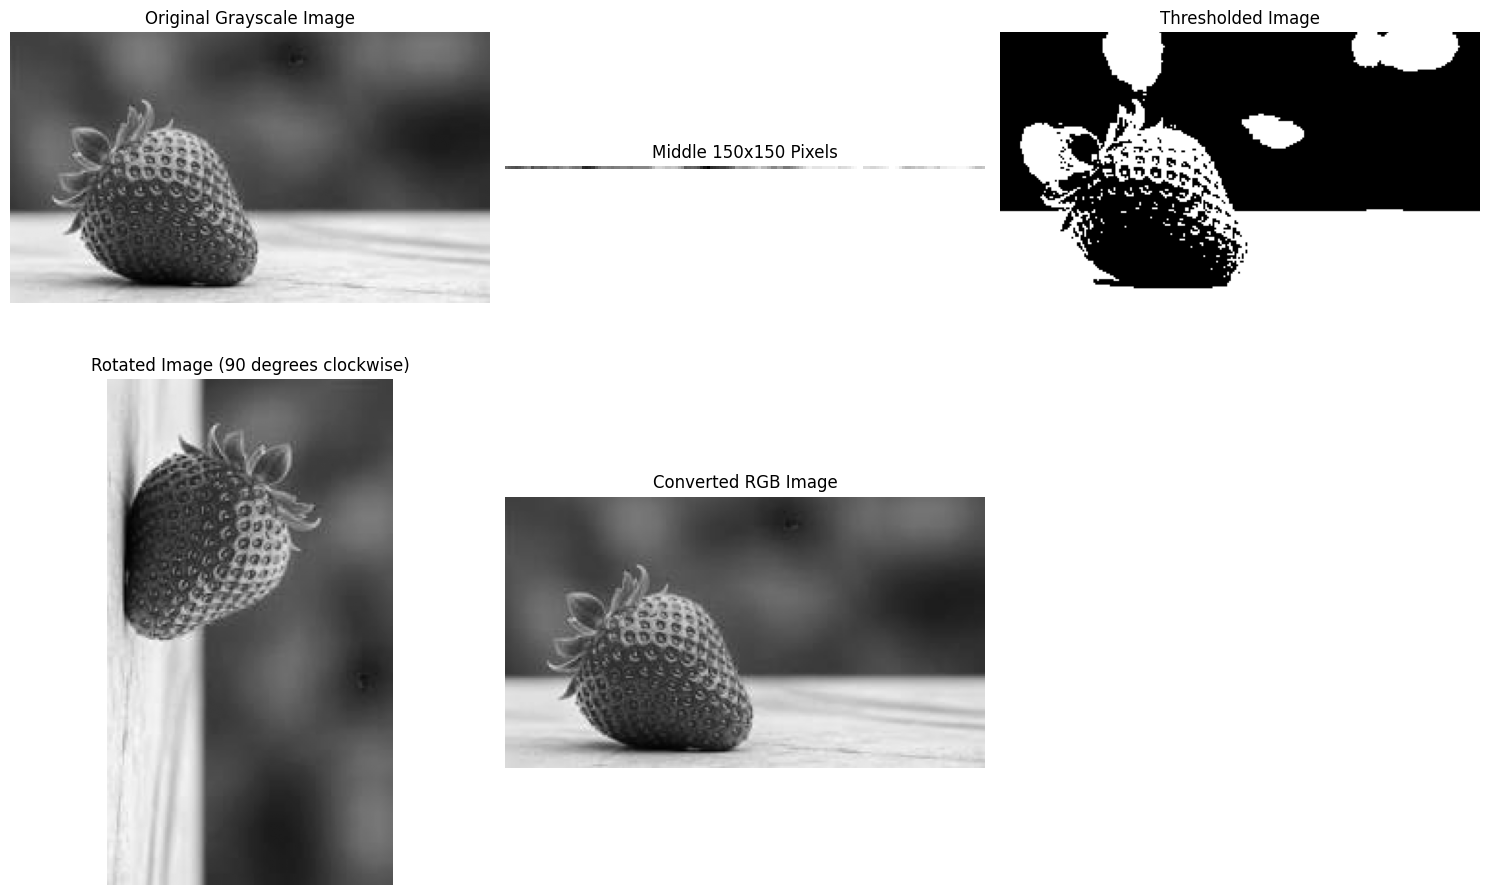

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Task 1 — Display grayscale
axes[0, 0].imshow(gray, cmap='gray')
axes[0, 0].set_title('Original Grayscale Image')
axes[0, 0].axis('off')

# Task 2 — Middle 150x150 section
h, w = gray.shape
mid_h, mid_w = h // 2, w // 2
middle = gray[mid_h - 75:mid_h + 75, mid_w - 75:mid_w + 75]

axes[0, 1].imshow(middle, cmap='gray')
axes[0, 1].set_title('Middle 150x150 Pixels')
axes[0, 1].axis('off')

# Task 3 — Threshold: <100 -> 0, >=100 -> 255
binary = gray.copy()
binary[binary < 100] = 0
binary[binary >= 100] = 255

axes[0, 2].imshow(binary, cmap='gray')
axes[0, 2].set_title('Thresholded Image')
axes[0, 2].axis('off')

# Task 4 — Rotate 90 degrees clockwise
rotated = np.rot90(gray, k=-1)

axes[1, 0].imshow(rotated, cmap='gray')
axes[1, 0].set_title('Rotated Image (90 degrees clockwise)')
axes[1, 0].axis('off')

# Task 5 — Convert grayscale to RGB
rgb_from_gray = np.stack([gray, gray, gray], axis=2)

axes[1, 1].imshow(rgb_from_gray)
axes[1, 1].set_title('Converted RGB Image')
axes[1, 1].axis('off')

axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

---
## Exercise 3 — PCA Image Compression from Scratch

### Step 1 — Load, Prepare & Standardise

In [10]:
gray_img = np.array(Image.open(io.BytesIO(gray_data)).convert('L'), dtype=float)

mean = np.mean(gray_img, axis=0)
std  = np.std(gray_img, axis=0)
std[std == 0] = 1

X_centered = gray_img - mean
X_std      = X_centered / std

cov_matrix = np.cov(X_std, rowvar=False)

print("Image shape    :", gray_img.shape)
print("Mean shape     :", mean.shape)
print("Cov matrix shape:", cov_matrix.shape)

Image shape    : (148, 262)
Mean shape     : (262,)
Cov matrix shape: (262, 262)


### Step 2 — Eigen Decomposition & Principal Components

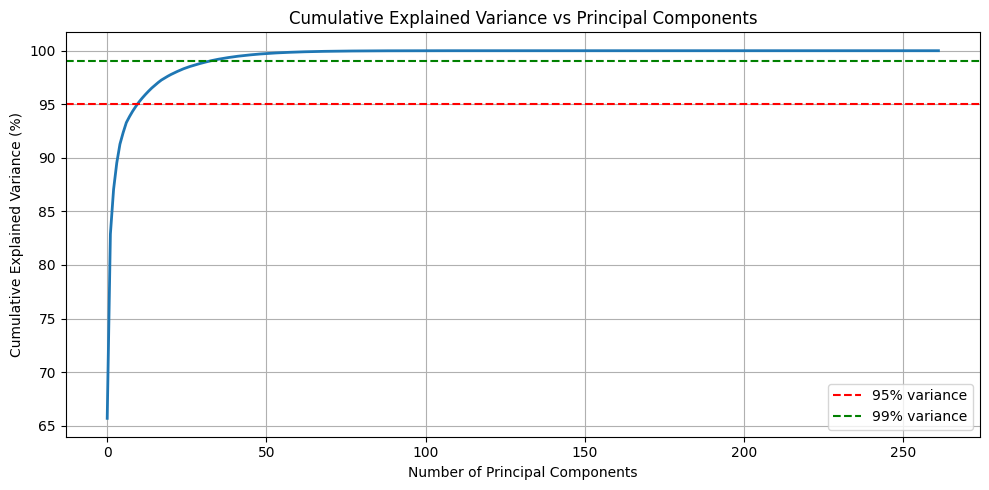

Components needed for 80% variance: 2
Components needed for 90% variance: 5
Components needed for 95% variance: 11
Components needed for 99% variance: 33


In [11]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_idx   = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

explained_variance     = eigenvalues / np.sum(eigenvalues)
cumulative_variance    = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance * 100, linewidth=2)
plt.axhline(y=95, color='r', linestyle='--', label='95% variance')
plt.axhline(y=99, color='g', linestyle='--', label='99% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance vs Principal Components')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

for pct in [80, 90, 95, 99]:
    k = np.argmax(cumulative_variance >= pct / 100) + 1
    print(f"Components needed for {pct}% variance: {k}")

### Step 3 — Reconstruction & Experiment with 4 k values

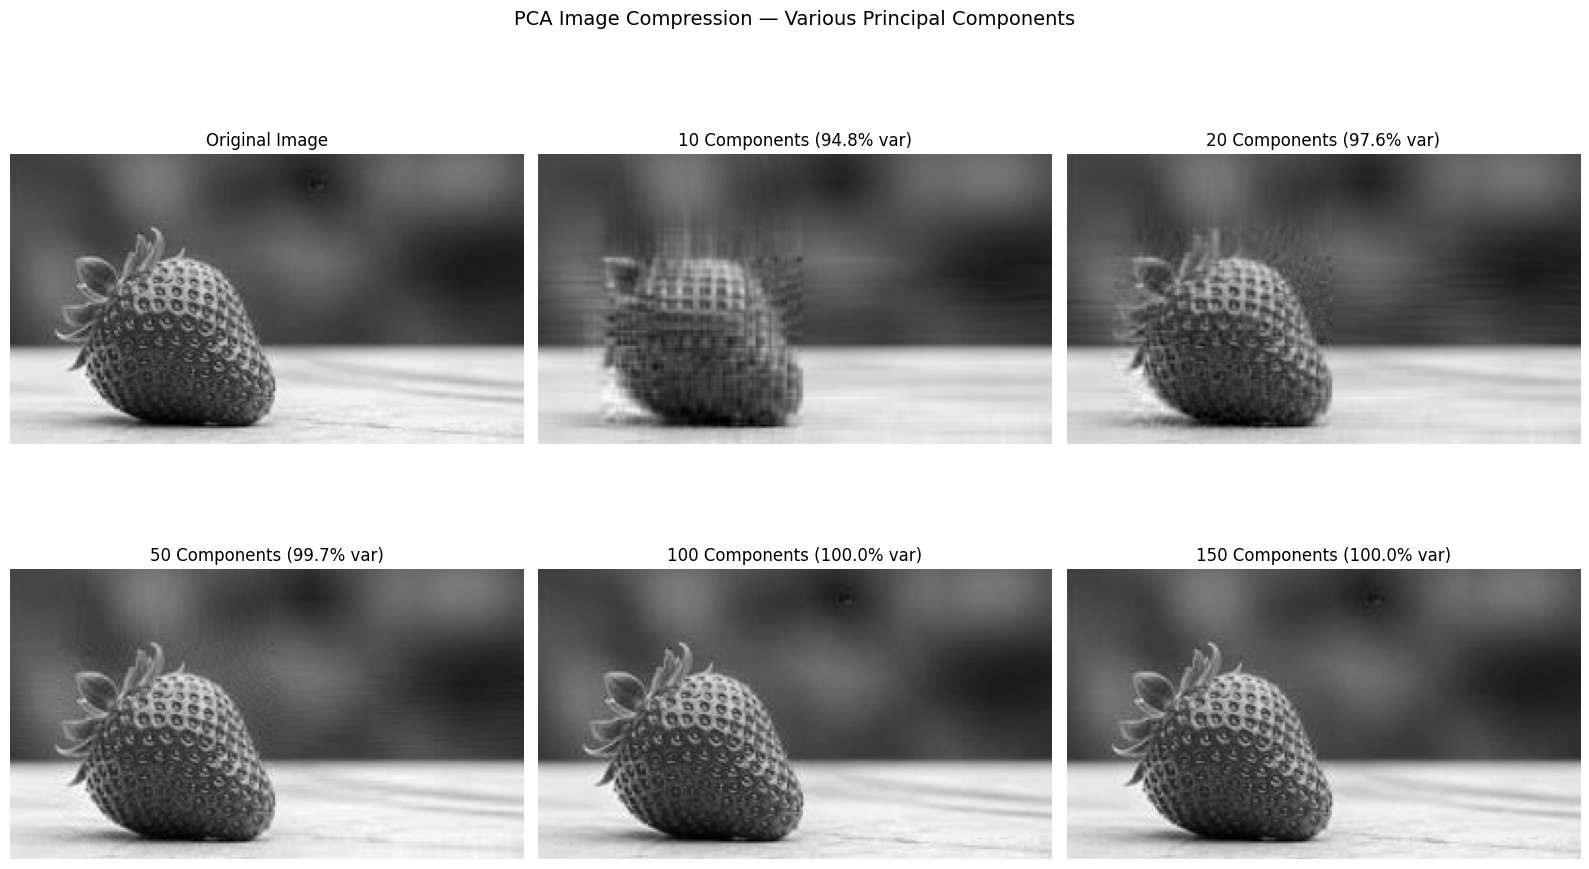

In [12]:
def pca_reconstruct(X_std, eigenvectors, k, mean, std):
    Vk          = eigenvectors[:, :k]
    compressed  = X_std @ Vk
    reconstructed_std = compressed @ Vk.T
    reconstructed     = (reconstructed_std * std) + mean
    reconstructed     = np.clip(reconstructed, 0, 255).astype(np.uint8)
    return reconstructed


k_values = [10, 20, 50, 100, 150]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

axes[0].imshow(gray_img.astype(np.uint8), cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

for i, k in enumerate(k_values):
    recon = pca_reconstruct(X_std, eigenvectors, k, mean, std)
    var   = cumulative_variance[k - 1] * 100
    axes[i + 1].imshow(recon, cmap='gray')
    axes[i + 1].set_title(f'{k} Components ({var:.1f}% var)')
    axes[i + 1].axis('off')

plt.suptitle('PCA Image Compression — Various Principal Components', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
print(f"{'Components':<15} {'Var Explained':<20} {'MSE':<15} {'PSNR (dB)':<12}")
print("-" * 62)

for k in k_values:
    recon = pca_reconstruct(X_std, eigenvectors, k, mean, std)
    mse   = np.mean((gray_img - recon.astype(float)) ** 2)
    psnr  = 10 * np.log10((255 ** 2) / mse) if mse > 0 else float('inf')
    var   = cumulative_variance[k - 1] * 100
    print(f"{k:<15} {var:<20.2f} {mse:<15.2f} {psnr:<12.2f}")

Components      Var Explained        MSE             PSNR (dB)   
--------------------------------------------------------------
10              94.81                112.34          27.63       
20              97.62                54.19           30.79       
50              99.71                7.71            39.26       
100             100.00               0.52            50.96       
150             100.00               0.50            51.15       
